[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jecampagne/nufftacf/blob/corrf/notebook/nufftacf_ccf_demo.ipynb)


# CCF for irregularly-sampled signals: nufftacf vs pyZDCF

This notebook demonstrates and compares three approaches to the
**cross-correlation function (CCF)** of two independently-sampled
irregular time series:

  Method               | Algorithm               | Kernel                          |
 |----------------------|--------------------------|---------------------------------|
 | **nufftacf**         | NUFFT + Wiener-Khinchin  | Gaussian or Rectangle (`bin_width`) |
 | **pyZDCF**           | Z-transformed DCF (Alexander 1997) | Adaptive binning (`minpts`) |

Test series mirror the irregularly-sampled STS_SIN* / STS_EXP* series from
`pastas_vs_nufftact.ipynb`, extended to the CCF by introducing a known
time delay τ₀ between two observation networks sampling the same process.

## Installation Note
> The **pyzdcf** repository was cloned and adapted to ensure compatibility with the pandas and other library versions used in this notebook, allowing it to run on Google Colab. These changes do not affect the quality of the computations.
> Additionally, **pyzdcf** requires CSV files as input (not NumPy arrays directly). A helper function, `run_zdcf_ccf`, is provided below to handle temporary file creation transparently.

In [15]:
!pip -q install   "pyzdcf @ git+https://github.com/jecampagne/pyzdcf.git"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [16]:
!pip -q install   "nufftacf @ git+https://github.com/jecampagne/nufftacf.git@corrf"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [17]:
import io, os, contextlib, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyzdcf import pyzdcf as _pyzdcf

from nufftacf import (
    compute_ccf_gaussian_nufft,
    compute_ccf_rectangle_nufft,
    compute_ccf_gaussian_realspace,
)

import nufftacf
print(f"nufftacf : {nufftacf.__version__}")
try:
    import pyzdcf as _pz; print(f"pyzdcf   : {_pz.__version__}")
except AttributeError:
    print("pyzdcf   : (version not exposed)")


nufftacf : 0.1.0
pyzdcf   : (version not exposed)


In [18]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size'         : 13,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 14,
    'xtick.labelsize'   : 14,
    'ytick.labelsize'   : 14,
    'legend.fontsize'   : 12,
    'figure.titlesize'  : 16,
    'figure.titleweight': 'bold',
})

## Helper: run pyZDCF CCF from numpy arrays

pyZDCF requires CSV files as input. This helper wraps the call
transparently so the rest of the notebook works with numpy arrays.


In [19]:
def run_zdcf_ccf(t, x, s, y, minpts=11, num_MC=100, err_frac=0.01):
    """Run pyZDCF cross-correlation between (t, x) and (s, y).

    Parameters
    ----------
    t, x    : times and values of signal 1 (sorted ascending)
    s, y    : times and values of signal 2 (sorted ascending)
    minpts  : minimum pairs per lag bin  (controls lag resolution)
    num_MC  : Monte Carlo runs for error estimation
    err_frac: fractional flux error (synthetic data — small constant)

    Returns
    -------
    DataFrame with columns:
    ['tau', '-sig(tau)', '+sig(tau)', 'dcf', '-err(dcf)', '+err(dcf)', '#bin']
    """
    err_x = np.full(len(t), err_frac * (np.std(x) or 1.0))
    err_y = np.full(len(s), err_frac * (np.std(y) or 1.0))
    input_dir  = tempfile.mkdtemp() + "/"
    output_dir = tempfile.mkdtemp() + "/"
    np.savetxt(input_dir + "lc_x.csv", np.column_stack([t, x, err_x]), delimiter=",")
    np.savetxt(input_dir + "lc_y.csv", np.column_stack([s, y, err_y]), delimiter=",")
    params = dict(
        autocf=False, prefix="zdcf", uniform_sampling=False,
        omit_zero_lags=True, minpts=minpts, num_MC=num_MC,
        lc1_name="lc_x.csv", lc2_name="lc_y.csv",
    )
    with contextlib.redirect_stdout(io.StringIO()):
        result = _pyzdcf(
            input_dir=input_dir, output_dir=output_dir,
            intr=False, sep=",", verbose=False, sparse="auto",
            parameters=params,
        )
    return result


# First Test series

Two observation networks X and Y sampling the same underlying process,
with a known time delay **τ₀** between them.

- **x(t)**: observations at irregular times t ⊂ [0, 3650 days] (~43 % kept)
- **y(s)**: same process values, times shifted by τ₀ days (same irregularity structure)
- The CCF should peak at **τ = τ₀** for both SIN and EXP series.

Common reference date is used for t and s so that the τ₀ offset is
preserved in numeric coordinates (see notebook comment).


In [20]:
n_days   = 3650
tau_0    = 60
idx_full = pd.date_range(start="2000-01-01", periods=n_days, freq="D")
ref_date = idx_full[0]
rng      = np.random.default_rng(42)

# --- underlying processes ---
sin_full = np.sin(2 * np.pi * idx_full.dayofyear / 365.25)

alpha    = 10.0
kern_b   = np.exp(-np.arange(200) / alpha)
noise    = rng.standard_normal(n_days + 200)
exp_full = np.convolve(noise, kern_b, mode="valid")[:n_days]
exp_full = (exp_full - exp_full.mean()) / exp_full.std()

# --- observation networks ---
mask_x   = rng.random(n_days) > 0.57    # ~43 % kept
idx_x    = idx_full[mask_x]
idx_y    = idx_x + pd.Timedelta(days=tau_0)

def t_common(idx):
    """Elapsed days from the common reference date (preserves tau_0 offset)."""
    return (idx - ref_date).days.to_numpy(dtype=float)

t_num = t_common(idx_x)
s_num = t_common(idx_y)   # = t_num + tau_0

for name, val in [("SIN", sin_full), ("EXP", exp_full)]:
    print(f"{name}: n_x=n_y={mask_x.sum()}  tau_0={tau_0} d"
          f"  t in [{t_num.min():.0f}, {t_num.max():.0f}]"
          f"  s in [{s_num.min():.0f}, {s_num.max():.0f}]")


SIN: n_x=n_y=1517  tau_0=60 d  t in [2, 3647]  s in [62, 3707]
EXP: n_x=n_y=1517  tau_0=60 d  t in [2, 3647]  s in [62, 3707]


## Computing CCF with all three methods

In [21]:
lags     = np.arange(1.0, 181.0)
bin_width = 0.5

results = {}
for name, val_full in [("SIN", sin_full), ("EXP", exp_full)]:
    x = val_full[mask_x]
    y = val_full[mask_x]   # same values, observed tau_0 days later via idx_y

    print(f"--- {name} ---")
    c_gn, b_gn = compute_ccf_gaussian_nufft(lags, t_num, x, s_num, y, bin_width=bin_width)
    c_rn, b_rn = compute_ccf_rectangle_nufft(lags, t_num, x, s_num, y, bin_width=bin_width)
    c_gr, b_gr = compute_ccf_gaussian_realspace(lags, t_num, x, s_num, y, bin_width=bin_width)

    print(f"  nufftacf gaussian  peak={c_gn.max():.4f} @ lag={lags[np.argmax(c_gn)]:.0f}")
    print(f"  nufftacf rectangle peak={c_rn.max():.4f} @ lag={lags[np.argmax(c_rn)]:.0f}")
    print(f"  realspace gaussian  peak={c_gr.max():.4f} @ lag={lags[np.argmax(c_gr)]:.0f}")

    print(f"  pyZDCF (minpts=11, MC=100) ...", end=" ", flush=True)
    zdcf = run_zdcf_ccf(t_num, x, s_num, y, minpts=11, num_MC=100)
    idx_z = np.argmax(zdcf["dcf"].to_numpy())
    print(f"peak={zdcf['dcf'].iloc[idx_z]:.4f} @ lag={zdcf['tau'].iloc[idx_z]:.1f}"
          f"  ({len(zdcf)} bins)")

    results[name] = dict(
        c_gn=c_gn, b_gn=b_gn,
        c_rn=c_rn, b_rn=b_rn,
        c_gr=c_gr, b_gr=b_gr,
        zdcf=zdcf,
        x=x, y=y,
    )


--- SIN ---
  nufftacf gaussian  peak=1.0181 @ lag=66
  nufftacf rectangle peak=1.0284 @ lag=66
  realspace gaussian  peak=1.0185 @ lag=63
  pyZDCF (minpts=11, MC=100) ... peak=0.9982 @ lag=62.1  (105 bins)
--- EXP ---
  nufftacf gaussian  peak=1.0000 @ lag=60
  nufftacf rectangle peak=1.0000 @ lag=60
  realspace gaussian  peak=1.0000 @ lag=60
  pyZDCF (minpts=11, MC=100) ... peak=0.8924 @ lag=58.0  (105 bins)


## Plots

In [40]:
def plot_ccf_comparison(name, res, tau_0, lags):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    fig.suptitle(fr"{name} series  ($\tau_0$={tau_0} d)", fontsize=13)

    z     = res["zdcf"]
    tau_z = z["tau"].to_numpy()
    dcf_z = z["dcf"].to_numpy()
    elo   = z["-err(dcf)"].to_numpy()
    ehi   = z["+err(dcf)"].to_numpy()
    n_bins = len(z)

    for ax, title, show_rect in zip(axes,
        ["nufftacf gaussian vs pyZDCF", "nufftacf rectangle vs pyZDCF"],
        [False, True]):

        # pyZDCF avec barres d'erreur
        ax.errorbar(tau_z, dcf_z, yerr=[elo, ehi],
                    fmt="o", ms=6, color="green", elinewidth=0.8, capsize=2,
                    label=f"pyZDCF (minpts=11) — {n_bins} bins", zorder=2)

        # nufftacf
        ax.plot(lags, res["c_gn"], color="blue", lw=2,
                label="nufftacf gaussian", zorder=3)
        if show_rect:
            ax.plot(lags, res["c_rn"], color="orange", lw=2, ls="--",
                    label="nufftacf rectangle", zorder=3)
        else:
            ax.plot(lags, res["c_gr"], color="cyan", lw=1.5, ls="-.",
                    label="nufftacf realspace (ref)", zorder=3)

        ax.axvline(tau_0, color="k", lw=3, ls="--", alpha=0.7,
                   label=f"true tau_0={tau_0} d")
        ax.set_xlabel("Lag [days]")
        ax.set_ylabel("CCF")
        ax.set_title(title)
        ax.set_xlim(0, lags.max())
        ax.set_ylim(-0.5, 1.1)
        ax.legend()

    plt.tight_layout()
    plt.show()

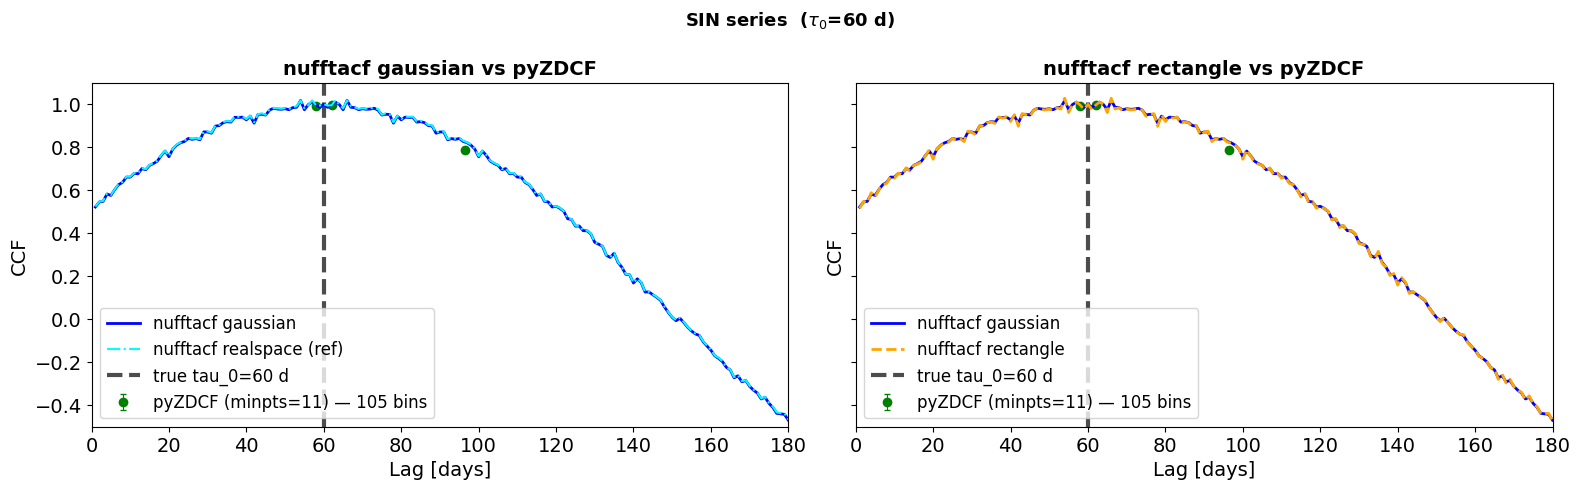

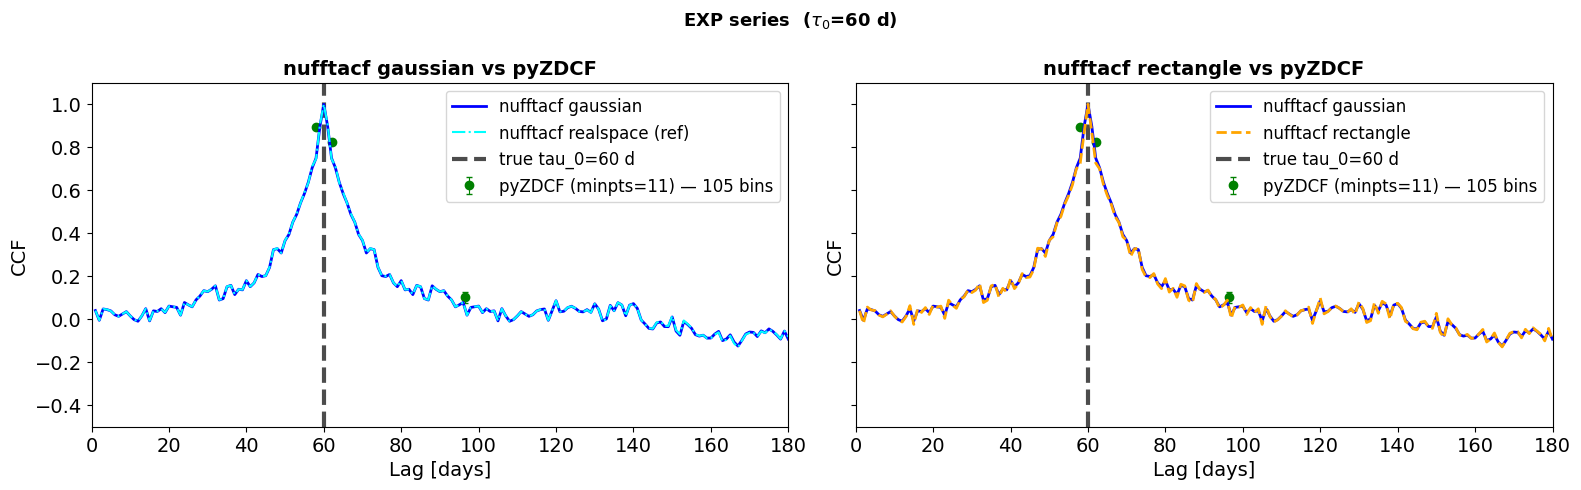

In [41]:
for name, res in results.items():
    plot_ccf_comparison(name, res, tau_0, lags)


## Effect of delay τ₀ on CCF peak quality

EXP series with three delays (20, 60, 120 days) — nufftacf gaussian vs pyZDCF.


In [24]:
lags     = np.arange(1.0, 181.0)
bin_width = 0.5

results_bis = {}
for tau in [20, 60, 120]:
    # rebuild series with this tau
    idx_y2 = idx_x + pd.Timedelta(days=tau)
    s2     = t_common(idx_y2)
    x2     = exp_full[mask_x]
    y2     = exp_full[mask_x]

    c_gn2, _ = compute_ccf_gaussian_nufft(lags, t_num, x2, s2, y2, bin_width=0.5)
    zdcf2     = run_zdcf_ccf(t_num, x2, s2, y2, minpts=11, num_MC=100)
    results_bis[tau] = dict(
        c_gn2=c_gn2,
        zdcf2=zdcf2
    )

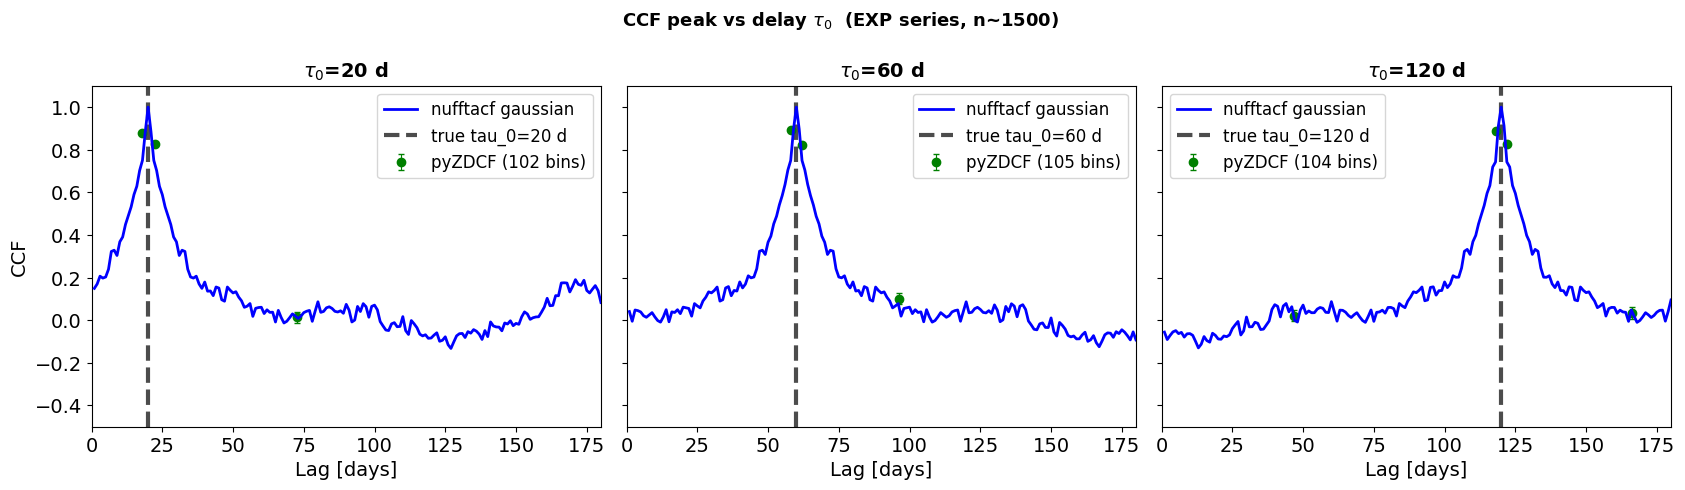

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle(r"CCF peak vs delay $\tau_0$  (EXP series, n~1500)", fontsize=13)

for ax, tau in zip(axes, [20, 60, 120]):

    c_gn2 = results_bis[tau]["c_gn2"]
    z2    = results_bis[tau]["zdcf2"]

    tau_z2= z2["tau"].to_numpy(); dcf_z2=z2["dcf"].to_numpy()
    elo2  = z2["-err(dcf)"].to_numpy(); ehi2=z2["+err(dcf)"].to_numpy()

    ax.errorbar(tau_z2, dcf_z2, yerr=[elo2, ehi2],
                fmt="o", ms=6, color="green", elinewidth=0.8, capsize=2,
                label=f"pyZDCF ({len(z2)} bins)", zorder=2)
    ax.plot(lags, c_gn2, color="blue", lw=2, label="nufftacf gaussian", zorder=3)
    ax.axvline(tau, color="k", lw=3, ls="--", alpha=0.7,
                   label=f"true tau_0={tau} d")
    ax.set_title(fr"$\tau_0$={tau} d")
    ax.set_xlabel("Lag [days]")
    if ax is axes[0]: ax.set_ylabel("CCF")
    ax.set_xlim(0, lags.max()); ax.set_ylim(-0.5, 1.1)
    ax.legend()

plt.tight_layout()
plt.show()


# Secund Test Case: Coupled Ornstein-Uhlenbeck Processes (Variable rho)

We construct two **independent** latent Ornstein-Uhlenbeck processes, e1(t) and e2(t),
(both with the same ACF form as the EXP case: `ACF(u) = exp(- u|/alpha)`), then we define:

```
X1(t) = e1(t)
X2(t) = rho * e1(t - tau_0)  +  sqrt(1 - rho**2) * e2(t)
```

The lag `tau_0` is here **physical** (X2 is truly a delayed and partially noisy version of X1),
unlike the previous SIN/EXP case where the shift was only an artifact in the timestamps.

**Theoretical Truth**:

    ACF_X1(u) = ACF_X2(u) = exp(-|u| / alpha)
    CCF_theoretical(tau) = rho * exp(-|tau - tau_0| / alpha)

Exact peak at tau = tau_0, with height rho.

The two observation networks sample their own irregular grids: network 1 retains ~40% of the days,
network 2 retains ~60% of the days (independent masks), with no artificial timestamp shift.

In [26]:
# --- new parameters (n_days, lags, bin_width, idx_full, ref_date, t_common) ---
alpha_xy = 10.0
tau_0_xy = 60
rhos     = [0.1, 0.4, 0.7, 0.95]

rng_xy = np.random.default_rng(123)

def make_ou(rng, n, alpha, buffer=200):
    """Generate a unit-variance Ornstein-Uhlenbeck-like process via causal exponential filtering of white noise."""
    noise = rng.standard_normal(n + buffer)
    kern  = np.exp(-np.arange(buffer) / alpha)
    e     = np.convolve(noise, kern, mode="valid")[:n]
    return (e - e.mean()) / e.std()

# e1_full covers t = -tau_0_xy ... n_days-1 (required past for X2(t)=...e1(t-tau_0)...)
e1_full = make_ou(rng_xy, n_days + tau_0_xy, alpha_xy)
e2_full = make_ou(rng_xy, n_days, alpha_xy)

X1_full     = e1_full[tau_0_xy:]     # e1(t),          t = 0..n_days-1
X1_delayed  = e1_full[:n_days]       # e1(t - tau_0),  t = 0..n_days-1

mask1 = rng_xy.random(n_days) > 0.6
mask2 = rng_xy.random(n_days) > 0.4

idx1 = idx_full[mask1]
idx2 = idx_full[mask2]
t1_num = t_common(idx1)
t2_num = t_common(idx2)

print(f"(X1): n={mask1.sum()} (X2): n={mask2.sum()}")
print(f"tau_0={tau_0_xy} d  alpha={alpha_xy}  rhos={rhos}")


(X1): n=1473 (X2): n=2205
tau_0=60 d  alpha=10.0  rhos=[0.1, 0.4, 0.7, 0.95]


## Computing CCF

In [27]:
lags_xy     = np.arange(1.0, 181.0)
bin_width_xy = 0.5

results_xy = {}
for rho in rhos:
    X2_full = rho * X1_delayed + np.sqrt(1 - rho**2) * e2_full

    x1 = X1_full[mask1]
    x2 = X2_full[mask2]

    print(f"--- rho={rho} ---")
    c_gn, b_gn = compute_ccf_gaussian_nufft(lags_xy, t1_num, x1, t2_num, x2, bin_width=bin_width_xy)
    c_rn, b_rn = compute_ccf_rectangle_nufft(lags_xy, t1_num, x1, t2_num, x2, bin_width=bin_width_xy)

    print(f"  nufftacf gaussian  peak={c_gn.max():.4f} @ lag={lags_xy[np.argmax(c_gn)]:.0f}")
    print(f"  nufftacf rectangle peak={c_rn.max():.4f} @ lag={lags_xy[np.argmax(c_rn)]:.0f}")

    print(f"  pyZDCF (minpts=11, MC=100) ...", end=" ", flush=True)
    zdcf = run_zdcf_ccf(t1_num, x1, t2_num, x2, minpts=11, num_MC=100)
    # pyZDCF also explores very distant lags (few pairs -> noise);
    # we restrict the peak search to the window [0, lags_xy.max()] studied here
    zsub = zdcf[(zdcf["tau"] >= lags_xy.min()) & (zdcf["tau"] <= lags_xy.max())]
    if len(zsub):
        i_max = zsub["dcf"].idxmax()
        print(f"peak={zsub.loc[i_max, 'dcf']:.4f} @ lag={zsub.loc[i_max, 'tau']:.1f}"
              f"  ({len(zdcf)} bins in total, {len(zsub)} in [0,{lags_xy.max():.0f}])")
    else:
        print(f"no bin pyZDCF in [0,{lags_xy.max():.0f}] ({len(zdcf)} bins in total)")

    truth = rho * np.exp(-np.abs(lags_xy - tau_0_xy) / alpha_xy)

    results_xy[rho] = dict(c_gn=c_gn, c_rn=c_rn, zdcf=zdcf, truth=truth, x1=x1, x2=x2)


--- rho=0.1 ---
  nufftacf gaussian  peak=0.1673 @ lag=167
  nufftacf rectangle peak=0.1777 @ lag=167
  pyZDCF (minpts=11, MC=100) ... peak=0.0720 @ lag=178.7  (186 bins in total, 4 in [0,180])
--- rho=0.4 ---
  nufftacf gaussian  peak=0.4455 @ lag=60
  nufftacf rectangle peak=0.4511 @ lag=60
  pyZDCF (minpts=11, MC=100) ... peak=0.1062 @ lag=80.9  (186 bins in total, 4 in [0,180])
--- rho=0.7 ---
  nufftacf gaussian  peak=0.7241 @ lag=60
  nufftacf rectangle peak=0.7332 @ lag=60
  pyZDCF (minpts=11, MC=100) ... peak=0.1375 @ lag=80.9  (186 bins in total, 4 in [0,180])
--- rho=0.95 ---
  nufftacf gaussian  peak=0.9617 @ lag=60
  nufftacf rectangle peak=0.9731 @ lag=60
  pyZDCF (minpts=11, MC=100) ... peak=0.1541 @ lag=80.9  (186 bins in total, 4 in [0,180])


## Plots

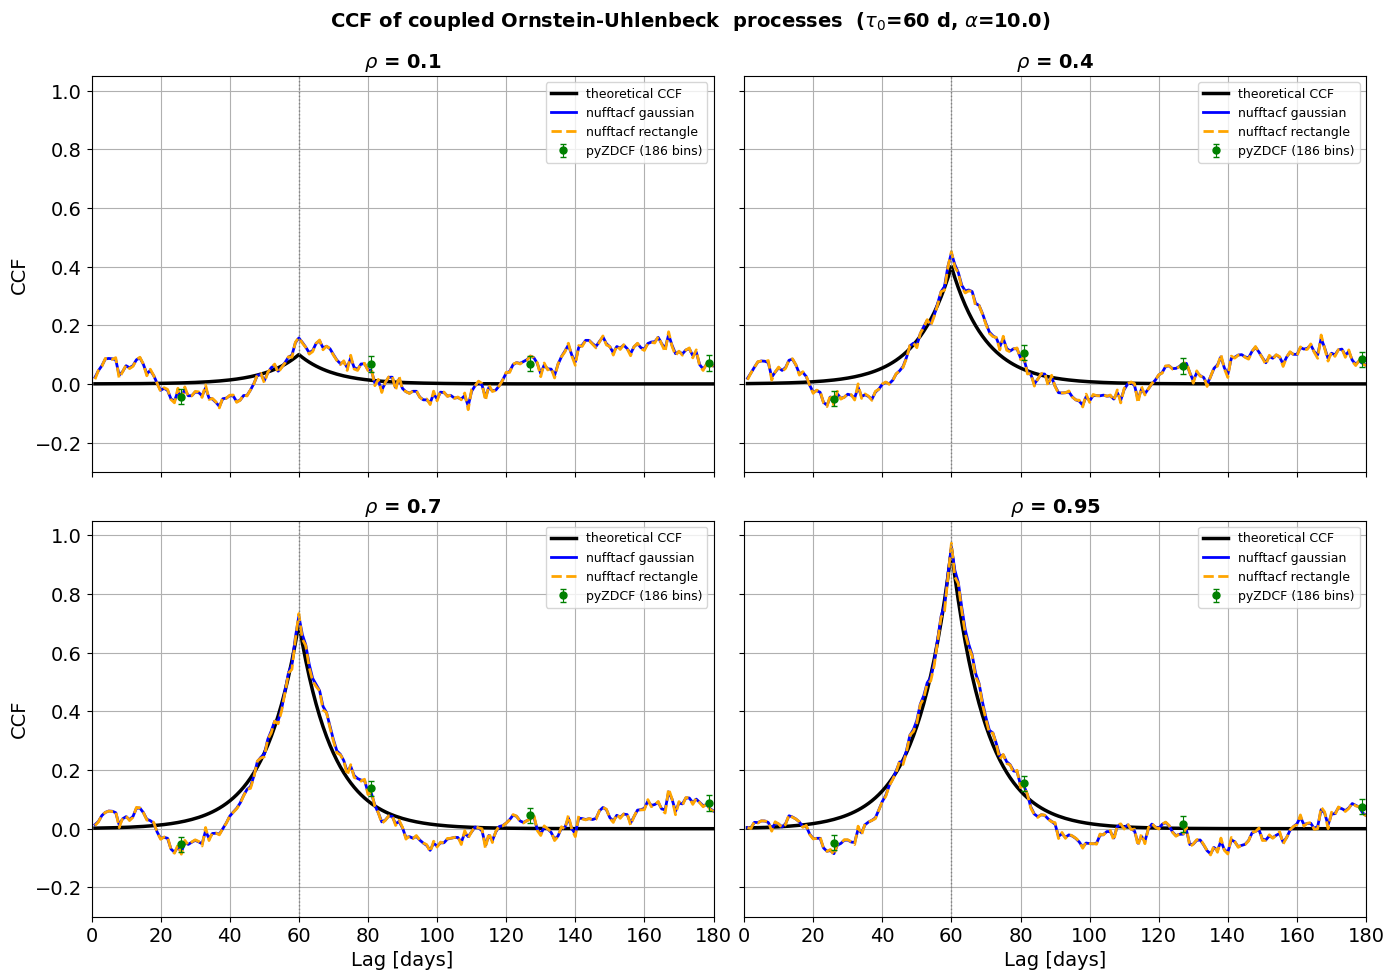

In [37]:
def plot_xy_case(results_xy, rhos, lags, tau_0, alpha):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
    fig.suptitle(fr"CCF of coupled Ornstein-Uhlenbeck  processes  ($\tau_0$={tau_0} d, $\alpha$={alpha})", fontsize=14)

    for ax, rho in zip(axes.flat, rhos):
        res = results_xy[rho]
        z     = res["zdcf"]
        tau_z = z["tau"].to_numpy()
        dcf_z = z["dcf"].to_numpy()
        elo   = z["-err(dcf)"].to_numpy()
        ehi   = z["+err(dcf)"].to_numpy()

        ax.plot(lags, res["truth"], color="black", lw=2.5, label="theoretical CCF")
        ax.plot(lags, res["c_gn"], color="blue", lw=2, label="nufftacf gaussian")
        ax.plot(lags, res["c_rn"], color="orange", lw=2, ls="--", label="nufftacf rectangle")
        ax.errorbar(tau_z, dcf_z, yerr=[elo, ehi],
                    fmt="o", ms=5, color="green", elinewidth=0.8, capsize=2,
                    label=f"pyZDCF ({len(z)} bins)", zorder=2)

        ax.axvline(tau_0, color="gray", lw=1, ls=":")
        ax.set_title(fr"$\rho$ = {rho}")
        ax.set_xlim(0, lags.max())
        ax.set_ylim(-0.3, 1.05)
        ax.legend(fontsize=9)

    for ax in axes[:, 0]:
        ax.set_ylabel("CCF")
    for ax in axes[-1, :]:
        ax.set_xlabel("Lag [days]")
    for ax in axes.ravel():
        ax.grid()

    plt.tight_layout()
    plt.show()

plot_xy_case(results_xy, rhos, lags_xy, tau_0_xy, alpha_xy)